<a href="https://colab.research.google.com/github/insafroumy/Predicting-Bike-sharing-demand/blob/main/Bike_Sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount google drive

In [25]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Imports

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor # NEW
from sklearn import set_config
set_config(transform_output='pandas')
pd.set_option('display.max_colwidth', 70)

## Load the data

In [27]:
#loading the data and print the first 5 rows
fpath = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week08/Data/day.csv"
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Preprocessing

In [28]:
#update the columns' names
new_column_names = {
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather_condition',
    'temp': 'temp_celsius',
    'atemp': 'feeling_temp_celsius',
    'hum': 'humidity',
    'casual': 'casual_users',
    'registered': 'registered_users',
    'cnt': 'total_rentals'
}

df.rename(columns=new_column_names, inplace=True)

In [29]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   instant               731 non-null    int64  
 1   date                  731 non-null    object 
 2   season                731 non-null    int64  
 3   year                  731 non-null    int64  
 4   month                 731 non-null    int64  
 5   holiday               731 non-null    int64  
 6   weekday               731 non-null    int64  
 7   workingday            731 non-null    int64  
 8   weather_condition     731 non-null    int64  
 9   temp_celsius          731 non-null    float64
 10  feeling_temp_celsius  731 non-null    float64
 11  humidity              731 non-null    float64
 12  windspeed             731 non-null    float64
 13  casual_users          731 non-null    int64  
 14  registered_users      731 non-null    int64  
 15  total_rentals         7

,instant,date,season,year,month,holiday,weekday,workingday,weather_condition,temp_celsius,feeling_temp_celsius,humidity,windspeed,casual_users,registered_users,total_rentals
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [30]:
#check the duplicated rows
df.duplicated().sum()

np.int64(0)

In [31]:
# print the value counts for each column
for col in df.columns:
  print(df[col].value_counts())
  print()

instant
731    1
1      1
2      1
3      1
4      1
      ..
16     1
15     1
14     1
13     1
12     1
Name: count, Length: 731, dtype: int64

date
2012-12-31    1
2011-01-01    1
2011-01-02    1
2011-01-03    1
2011-01-04    1
             ..
2011-01-16    1
2011-01-15    1
2011-01-14    1
2011-01-13    1
2011-01-12    1
Name: count, Length: 731, dtype: int64

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

year
1    366
0    365
Name: count, dtype: int64

month
1     62
3     62
7     62
5     62
12    62
10    62
8     62
4     60
9     60
6     60
11    60
2     57
Name: count, dtype: int64

holiday
0    710
1     21
Name: count, dtype: int64

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

workingday
1    500
0    231
Name: count, dtype: int64

weather_condition
1    463
2    247
3     21
Name: count, dtype: int64

temp_celsius
0.265833    5
0.635000    5
0.564167    4
0.437500    4
0.484167    4
         

In [32]:
#check the null values
df.isna().sum()

,0
instant,0
date,0
season,0
year,0
month,0
holiday,0
weekday,0
workingday,0
weather_condition,0
temp_celsius,0


#### Note that the dataset is clean and it doesn't has any duplicated or Na values.



In [33]:
#Drop useless columns
df = df.drop(columns=['date', 'instant'] )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   season                731 non-null    int64  
 1   year                  731 non-null    int64  
 2   month                 731 non-null    int64  
 3   holiday               731 non-null    int64  
 4   weekday               731 non-null    int64  
 5   workingday            731 non-null    int64  
 6   weather_condition     731 non-null    int64  
 7   temp_celsius          731 non-null    float64
 8   feeling_temp_celsius  731 non-null    float64
 9   humidity              731 non-null    float64
 10  windspeed             731 non-null    float64
 11  casual_users          731 non-null    int64  
 12  registered_users      731 non-null    int64  
 13  total_rentals         731 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 80.1 KB


### Correlation between the features

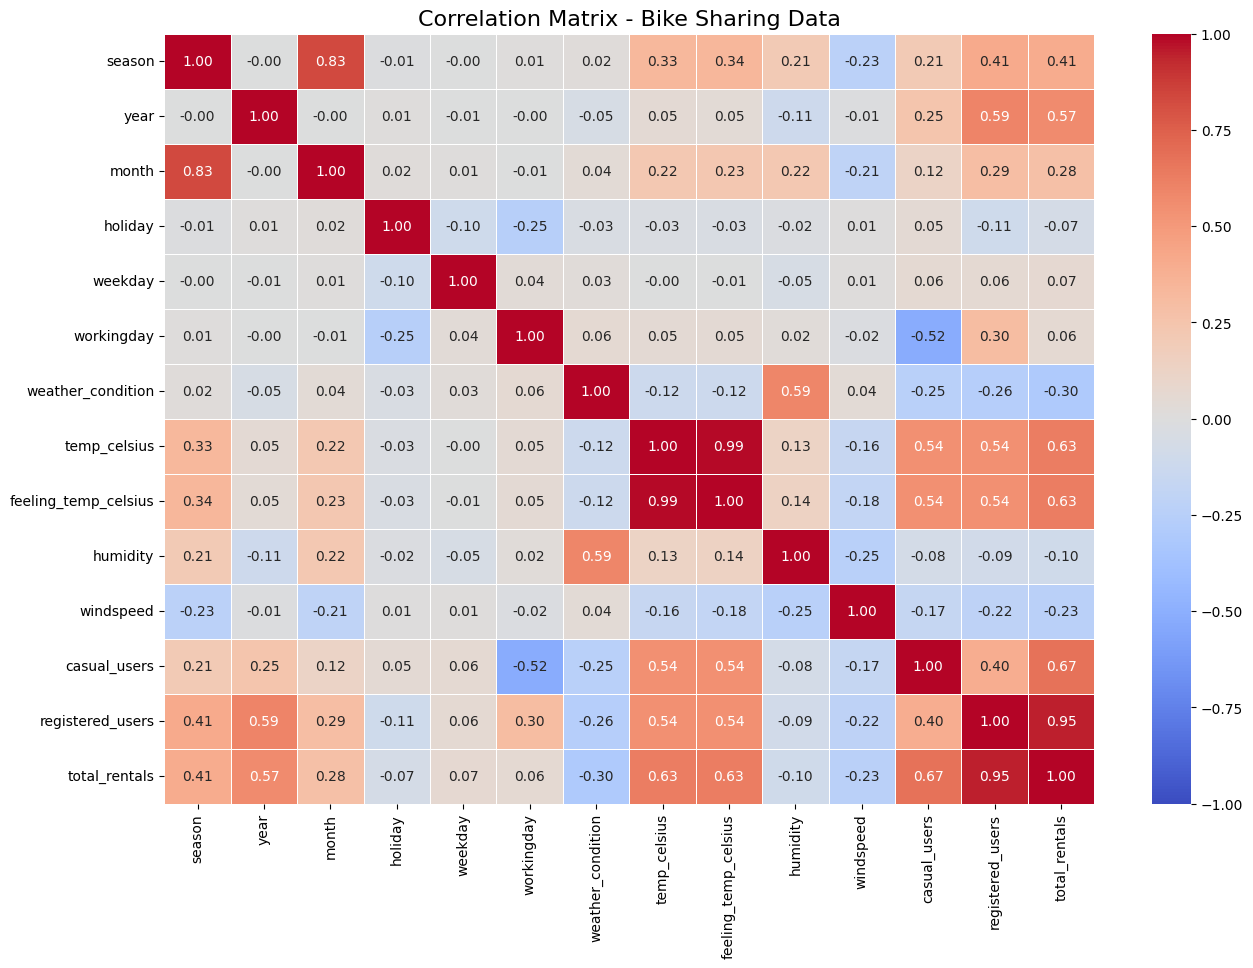

In [34]:
plt.figure(figsize=(15, 10))
corr = df.corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            center=0,
            vmin=-1, vmax=1)

plt.title('Correlation Matrix - Bike Sharing Data', fontsize=16)
plt.show()


## Split the data

In [35]:
# Arrange Data into Features Matrix and Target Vector
y = df['total_rentals']
X = df.drop(columns = ['total_rentals'])
# Split the data for validation
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [36]:
# Check for null values
X_train.isna().sum()

,0
season,0
year,0
month,0
holiday,0
weekday,0
workingday,0
weather_condition,0
temp_celsius,0
feeling_temp_celsius,0
humidity,0


## Preprocessing

In [37]:
# Save list of numeric columns
num_cols = X_train.select_dtypes('number').columns
# Constructing numeric preprocesssing objects
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
num_pipe = make_pipeline(num_imputer, scaler)
num_tuple = ('num',num_pipe, num_cols)
num_tuple

('num',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['season', 'year', 'month', 'holiday', 'weekday', 'workingday',
        'weather_condition', 'temp_celsius', 'feeling_temp_celsius', 'humidity',
        'windspeed', 'casual_users', 'registered_users'],
       dtype='object'))

In [38]:
# Define a column transformer
preprocessor  = ColumnTransformer([num_tuple],
                                  verbose_feature_names_out=False)

In [39]:
# Instantiate default random forest model
rf = RandomForestRegressor(random_state = 42)
# Model Pipeline
rf_pipe = make_pipeline(preprocessor, rf)

In [40]:
# Fit the model pipeline on the training data only
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['season', 'year', 'month', 'holiday', 'weekday', 'workingday',
       'weather_condition', 'temp_celsius', 'feeling_temp_celsius', 'humidity',
       'windspeed', 'casual_users', 'registered_users'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

## Custom Evaluation Functions

In [41]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics
def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )
  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

## Evaluate default model

In [42]:
# Use custom function to evaluate default model
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 31.867
- MSE = 2,223.607
- RMSE = 47.155
- R^2 = 0.999

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 66.384
- MSE = 10,185.498
- RMSE = 100.923
- R^2 = 0.997


## Apply Gridsearch

In [43]:
# Parameters for tuning
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['season', 'year', 'month', 'holiday', 'weekday', 'workingday',
          'weather_condition', 'temp_celsius', 'feeling_temp_celsius', 'humidity',
          'windspeed', 'casual_users', 'registered_users'],
         dtype='object'))],
                     verbose_feature_names_out=False)),
  ('randomforestregressor', RandomForestRegressor(random_state=42))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                          

In [44]:
# Define param grid with options to try
params = {'randomforestregressor__max_depth': [None,10,15,20],
          'randomforestregressor__n_estimators':[10,100,150,200],
          'randomforestregressor__min_samples_leaf':[2,3,4],
          'randomforestregressor__max_features':['sqrt','log2',None],
          'randomforestregressor__oob_score':[True,False],
          }

In [45]:
# Instantiate the gridsearch
gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv = 3, verbose=1)
# Fit the gridsearch on training data
gridsearch.fit(X_train, y_train)


Fitting 3 folds for each of 288 candidates, totalling 864 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['season', 'year', 'month', 'holiday', 'weekday', 'workingday',
       'weather_condition', 'temp_celsius', 'feeling_temp_celsius', 'humidity',
       'windspe...
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [None, 10, 15, 20],
                         'randomforestregressor__max_features': ['sqrt', 'log2',
                                                                 None],
                         'randomforestregressor__min_samples_leaf': [2, 3, 4],
                         'randomforestregressor__n_estimators': [10, 100, 150,
                                                                 200],
                         'randomforestregressor__oob_score': [True, False]},
             verbose=1)

In [46]:
# Obtain best parameters
gridsearch.best_params_

{'randomforestregressor__max_depth': 10,
 'randomforestregressor__max_features': None,
 'randomforestregressor__min_samples_leaf': 2,
 'randomforestregressor__n_estimators': 200,
 'randomforestregressor__oob_score': True}

##Fit and evaluate best model

In [47]:
# Define and refit best model
best_rf = gridsearch.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 36.082
- MSE = 3,301.556
- RMSE = 57.459
- R^2 = 0.999

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 66.209
- MSE = 10,153.358
- RMSE = 100.764
- R^2 = 0.997
